In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('Housing.csv')

In [67]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='str')


In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
le = LabelEncoder()

binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
print(X.head())


In [ ]:
print(y.head())

In [ ]:
# Simple Linear Regression
X_simple = df[["area"]]
y_simple = df["price"]

In [ ]:
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

In [ ]:
simple_model = LinearRegression()

simple_model.fit(X_train_simple, y_train_simple)

y_pred_simple = simple_model.predict(X_test_simple)

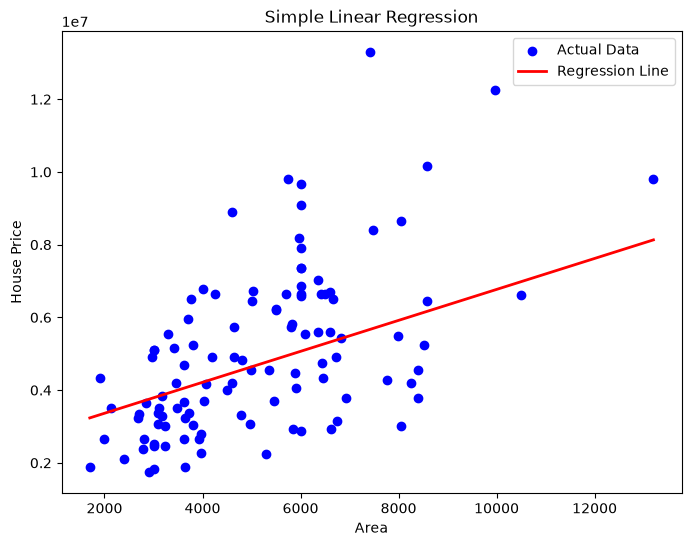

In [68]:
# Sort values so the line is drawn correctly
sorted_idx = np.argsort(X_test_simple["area"].values)

X_sorted = X_test_simple["area"].values[sorted_idx]
y_pred_sorted = y_pred_simple[sorted_idx]

plt.figure(figsize=(8,6))

plt.scatter(
    X_test_simple["area"],
    y_test_simple,
    color="blue",
    label="Actual Data"
)

plt.plot(
    X_sorted,
    y_pred_sorted,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

In [ ]:
mae = mean_absolute_error(y_test_simple, y_pred_simple)

mse = mean_squared_error(y_test_simple, y_pred_simple)

r2 = r2_score(y_test_simple, y_pred_simple)

In [66]:
print("Simple Linear Regression Results")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Simple Linear Regression Results
MAE: 1474748.1337969352
MSE: 3675286604768.185
R² Score: 0.27287851871974644


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
multiple_model = LinearRegression()

In [62]:
multiple_model.fit(X_train, y_train)
y_pred = multiple_model.predict(X_test)

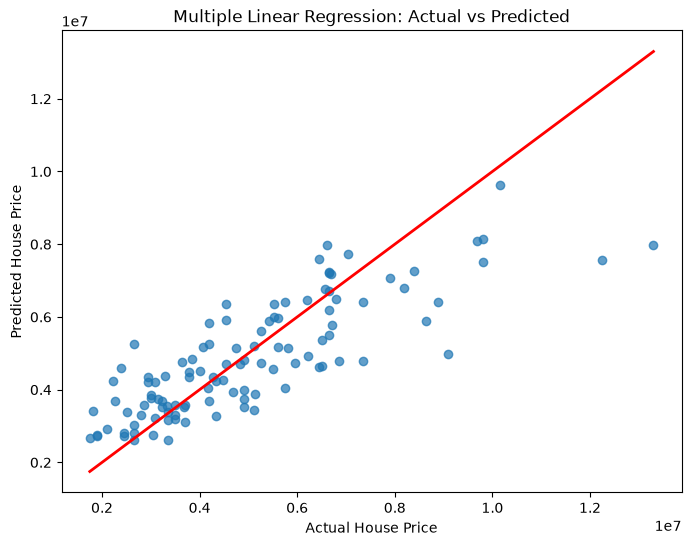

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.show()

In [65]:
mae_multiple = mean_absolute_error(y_test, y_pred)

mse_multiple = mean_squared_error(y_test, y_pred)

r2_multiple = r2_score(y_test, y_pred)

print("Multiple Linear Regression Results")
print("MAE:", mae_multiple)
print("MSE:", mse_multiple)
print("R² Score:", r2_multiple)

Multiple Linear Regression Results
MAE: 1474748.1337969352
MSE: 3675286604768.185
R² Score: 0.27287851871974644


In [63]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multiple_model.coef_
})

print(coefficients)

  Feature  Coefficient
0    area   425.729842


In [64]:
print("Intercept:", multiple_model.intercept_)

Intercept: 2512254.2639593435
